In [3]:
import os
import sys
import pandas as pd
import seaborn as sns
import itertools
import numpy as np
import scipy.stats as stats
import re
import math
import pybedtools
import mygene

mg = mygene.MyGeneInfo()

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [5]:
from matplotlib.colors import LinearSegmentedColormap

color_min    = "green"
color_center = "black"
color_max    = "red"
cmap = LinearSegmentedColormap.from_list(
    "cmap_name",
    [color_min, color_center, color_max]
)

In [6]:
import re

def atoi(text):
    return int(text) if text.isdigit() else text

def natural_keys(text):
    '''
    alist.sort(key=natural_keys) sorts in human order
    http://nedbatchelder.com/blog/200712/human_sorting.html
    (See Toothy's implementation in the comments)
    '''
    return [ atoi(c) for c in re.split(r'(\d+)', text) ]

def natural_keys_series(series):
    return series.map(natural_keys)

In [7]:
def add_annotations_with_error_bars(ax, df, which_annotations, annotations, order, hue_order, offset=0, fontsize=12):
    """
    Adds annotations (e.g., asterisks) to every 2nd bar in a hue group on a Seaborn barplot,
    taking into account the height of the error bars.

    Parameters:
    - ax: The axes object of the Seaborn plot.
    - annotations: A list of annotations (e.g., stars '*') to add.
    - hue_order: List of hue levels (optional).
    - order: List of x-axis categories (optional).
    - offset: Vertical offset for the annotations to position them above the bars and error bars.
    - fontsize: Font size of the annotations.
    """
    bars = ax.patches
    
    i_annotation = 0
    i_combination = 0
    
    # bars aren't necessarily in order but we can order them
    x_coords = [bar.get_x() for bar in bars]
    y_coords = [bar.get_height() for bar in bars]
    widths = [bar.get_width() for bar in bars]
    
    # filter out legend bars
    x_coords = [x_coord for i, x_coord in enumerate(x_coords) if widths[i] != 0]
    y_coords = [y_coord for i, y_coord in enumerate(y_coords) if widths[i] != 0]
    widths = [width for i, width in enumerate(widths) if widths[i] != 0]
    
    # add width to x_coords
    x_coords = [x_coord + widths[i]/2 for i, x_coord in enumerate(x_coords)]
    
    coords = [[x, y] for x, y in sorted(zip(x_coords, y_coords))]
    
    # Reconstruct bar order by matching x_labels and hues
    for i, label in enumerate(order):
        
        for j, hue_label in enumerate(hue_order):
            
            x = coords[i_combination][0]
            y = coords[i_combination][1]
            
            # check to see if this is a pair to be annotated
            if [label, hue_label] in which_annotations:
                
                if y < 0:
                    va = 'top'
                    
                    ax.text(
                        x,
                        y + offset,
                        annotations[i_annotation],
                        ha='center',
                        va=va,
                        fontsize=fontsize
                    )
                    
                else:
                    va = 'bottom'
                    
                    ax.text(
                        x,
                        y - offset,
                        annotations[i_annotation],
                        ha='center',
                        va=va,
                        fontsize=fontsize
                    )
                
                i_annotation += 1
                
            i_combination += 1

In [8]:
def get_annotations(df, order, hue_order, name_order, name_hue):
    
    which_annotations = []
    annotations = []
    
    for gene_set in order:
        for region in hue_order:

            which_annotations.append([gene_set, region])

            p_value = list(df.loc[(df[name_order] == gene_set) & (df[name_hue] == region)]['P(Fisher)'])[0]

            if p_value < 0.01:
                annotations.append('**')
            elif p_value < 0.05:
                annotations.append('*')
            else:
                annotations.append('ns')
        
    return annotations, which_annotations

In [9]:
def split_gene_intervals(df, category_field_num, value_field_num, skip_cols):
    """
    Expand each gene region into 2kbp intervals relative to TSS.
    Assumes input df has columns: chrom, start, end, gene, strand.
    """
    records = []
    interval_size = 2000

    for row in df.to_dict('records'):
        
        chrom = row['#chrom']
        start = row['start']
        end = row['stop']
        gene = row['gene']
        strand = row['strand']
        category = row[category_field_num]
        value = row[value_field_num]
        
        num_intervals = int((end - start) / interval_size)
        
        # Generate intervals
        for i, rel_start in enumerate(range(start, end, interval_size)):
            
            rel_end = rel_start + interval_size

            if strand == "+":
                i_bin = i 
            else:
                i_bin = num_intervals - i - 1

            # skip regions closest to TSS, they tell us nothing

            if skip_cols == 2:
                if i == 8 or i == 9 or i == 10 or i == 11:
                    continue
            elif skip_cols == 1:
                if i == 9 or i == 10:
                    continue

            interval_name = f"{gene}_{i_bin}"
            records.append([chrom, rel_start, rel_end, strand, interval_name, i_bin, category, value])

    return pd.DataFrame(records)


In [10]:
def permutation_test(df_counts, category_1, category_2, metric='overlap', n_permutations=10000):
    
    # Observed: total DMR overlap in this category_1
    observed_dmr = df_counts.loc[(df_counts['category_1'] == category_1) & 
                                  (df_counts['category_2'] == category_2)][metric].sum()
    
    # Generate null distribution by shuffling category_1 labels
    null_distribution = []
    
    for _ in range(n_permutations):
        # Shuffle category_1 labels (keeps DMR/No_DMR pairs intact)
        df_shuffled = df_counts.copy()
        df_shuffled['category_1'] = np.random.permutation(df_shuffled['category_1'].values)
        
        # Calculate DMR overlap for this category after shuffling
        null_dmr = df_shuffled.loc[(df_shuffled['category_1'] == category_1) & 
                                    (df_shuffled['category_2'] == category_2)][metric].sum()
        null_distribution.append(null_dmr)
    
    null_distribution = np.array(null_distribution)
    
    # One-tailed test for enrichment
    p_value = np.mean(null_distribution >= observed_dmr)
    
    return p_value
    
def intersection(bedtool_dmr, bedtool_genes):

    path_sizes = '/home/data/Shared/genome_reference_files/hg19/chrom_sizes/hg19_chrom_sizes.tsv'
    df_sizes = pd.read_csv(path_sizes, header=None, sep='\t')
    df_sizes[2] = 0
    df_sizes = df_sizes[[0,2,1]]
    bedtool_sizes = pybedtools.BedTool.from_dataframe(df_sizes)
    bedtool_no_dmr = bedtool_sizes.subtract(bedtool_dmr)

    intersection = bedtool_genes.intersect(bedtool_dmr, wo=True)
    intersection_v = bedtool_genes.intersect(bedtool_no_dmr, wo=True)
    
    df_intersection = intersection.to_dataframe(header=None, disable_auto_names=True)
    df_intersection_v = intersection_v.to_dataframe(header=None, disable_auto_names=True)

    intersection_records = []

    for record in df_intersection_v.to_dict('records'):

        record_length = len(record)
        
        gene = record[4]
        category_gene = record[6]
        interval = record[5]
        overlap = record[record_length-1]
    
        intersection_records.append({'gene': gene, 'category_2':'No', 'category_1':f'{category_gene}_{interval}', 'overlap':overlap}) 
    
    for record in df_intersection.to_dict('records'):

        record_length = len(record)
        
        gene = record[4]
        category_gene = record[6]
        interval = record[5]
        overlap = record[record_length-1]

        intersection_records.append({'gene': gene, 'category_2':'DMR', 'category_1':f'{category_gene}_{interval}', 'overlap':overlap}) 
    
    df_counts = pd.DataFrame(intersection_records)

    df_counts = df_counts.groupby(['gene', 'category_2', 'category_1']).sum()

    df_counts.reset_index(inplace=True)

    print(df_counts)
    
    df_counts['num_overlaps'] = np.where(
        df_counts['overlap'] < 500,
        0,
        1
    )
    
    #with pd.option_context('display.max_rows', None):
    #    df_counts_counts = df_counts.value_counts(subset=['category_1', 'category_2']).to_frame().reset_index()
    #    print(df_counts_counts.sort_values(by=['category_1', 'category_2']))

    categories_1 = list(set(df_counts['category_1'].tolist()))
    categories_2 = list(set(df_counts['category_2'].tolist()))
    
    #metric_for_odds = 'overlap'
    metric_for_odds = 'num_overlaps'
    
    df_bar_records = []
    
    for category_1 in categories_1:
    
        for category_2 in categories_2:

            a = np.sum(df_counts.loc[(df_counts['category_1'] == category_1) & (df_counts['category_2'] == category_2)][metric_for_odds])
            b = np.sum(df_counts.loc[(df_counts['category_1'] == category_1) & (df_counts['category_2'] != category_2)][metric_for_odds])
            c = np.sum(df_counts.loc[(df_counts['category_1'] != category_1) & (df_counts['category_2'] == category_2)][metric_for_odds])
            d = np.sum(df_counts.loc[(df_counts['category_1'] != category_1) & (df_counts['category_2'] != category_2)][metric_for_odds])

            if b == 0 or c == 0:
                df_bar_records.append({'category_1': category_1, 'category_2': str(category_2), 'ln(Odds Ratio)': 0, 'p': 1})
                continue
                
            log_odds_ratio = np.log((a * d) / (b * c))

            if log_odds_ratio > 0:
                p = stats.fisher_exact([[a, c], [b, d]], alternative='two-sided').pvalue
            else:
                p =1

            #p = permutation_test_dmr_enrichment(df_counts, category_1, category_2, metric=metric_for_odds, n_permutations=1000)
            
            df_bar_records.append({'category_1': category_1, 'category_2': str(category_2), 'ln(Odds Ratio)': log_odds_ratio, 'p': p})
        
    df_bar = pd.DataFrame(df_bar_records)

    df_bar.sort_values(by=['category_1', 'category_2'], inplace=True)

    print(df_bar)

    return df_bar

In [11]:
import matplotlib.ticker as mticker

def fmt_(v):
    if v == 12 or v==6 or v==20:     # only multiples of 4
        return f"+{v}"
    elif v == -12 or v==-6 or v==-20:
        return f"\u2212{abs(v)}"  # true minus
    else:
        return ""

def fmt(v):
    if v % 4 != 0:     # only multiples of 4
        return ""
    if v < 0:
        return f"\u2212{abs(v)}"  # true minus
    elif v > 0:
        return f"+{v}"
    else:
        return "0"

from scipy.stats import false_discovery_control

def add_significance_stars(ax, p_values, method='bonferroni', alpha=0.05):
    """
    Add significance stars to heatmap based on corrected p-values.
    
    Parameters:
    -----------
    ax : matplotlib axes
        The axes containing the heatmap
    p_values : DataFrame
        DataFrame of p-values matching heatmap dimensions
    method : str
        'bonferroni' or 'benjamini-hochberg' (or 'bh')
    alpha : float
        Significance threshold (default 0.05)
    
    Returns:
    --------
    corrected_p : DataFrame
        DataFrame of corrected p-values
    """

    # Add stars to heatmap
    p_values_values = p_values.values
    
    # Flatten p-values for correction
    p_flat = p_values.values.flatten()
    
    # Apply correction
    if method.lower() == 'bonferroni':
        n_tests = len(p_flat)
        corrected_p_flat = np.minimum(p_flat * n_tests, 1.0)
    elif method.lower() in ['benjamini-hochberg', 'bh']:
        # Use scipy's FDR correction
        corrected_p_flat = false_discovery_control(p_flat, method='bh')
    else:
        raise ValueError("method must be 'bonferroni' or 'benjamini-hochberg'")
    
    # Reshape back to original dimensions
    corrected_p = corrected_p_flat.reshape(p_values.shape)
    
    # Add stars to heatmap
    for i in range(len(p_values)):
        for j in range(len(p_values.columns)):
            p_val = corrected_p[i, j]

            p_val = p_values_values[i, j]
            
            # Determine significance level
            if p_val < 0.01:
                stars = '**'
            elif p_val < alpha:
                stars = '*'
            else:
                stars = ''
            
            # Add text to heatmap cell
            if stars:
                ax.text(j + 0.5, i + 0.5, stars,
                       ha='center', va='center',
                       color='white', fontsize=6)
    
    return corrected_p

def pivot(df, value_col):
    
    df_wide = df.pivot(index='gene_type', columns='position', values=value_col).reset_index()
    df_wide.sort_values(by='gene_type', key=natural_keys_series, inplace=True)
    df_wide.set_index('gene_type', inplace=True)

    # columns need to be sorted
    columns_sorted = list(df_wide.columns)
    columns_sorted.sort(key=natural_keys)
    df_wide = df_wide[columns_sorted]

    # rename columns
    df_wide.columns = [int((int(column)-10) * 2) for column in df_wide.columns]

    return df_wide

def plot_heatmap(df_bar, gene_type, name, y_labels):
    
    df_dmr = df_bar[df_bar['category_2'] == 'DMR']
    
    df_dmr['gene_type'] = df_dmr['category_1'].str.split('_', n=1).str[0]
    df_dmr['position'] = df_dmr['category_1'].str.split('_', n=1).str[-1]
    
    df_wide = pivot(df_dmr, 'ln(Odds Ratio)')
    df_wide_p = pivot(df_dmr, 'p')

    print(df_wide_p)
    
    fig, ax = plt.subplots()
    sns.heatmap(
        df_wide,
        ax=ax,
        cmap=cmap,
        center=0,
        vmax=df_wide.max().max(),
        vmin=-df_wide.max().max(),
        cbar_kws={'label': 'LOR Intersection'}
    )

    add_significance_stars(ax, df_wide_p, method='bh')
    
    #fig.set_size_inches(1.5, 1)
    fig.set_size_inches(2.5, 1)
    
    if 'tko' in name or 'hyper' in name:
        plt.title(f'Log Odds Intersection {name.upper()}/WT Hyper DMRs')
    else:
        plt.title(f'Log Odds Intersection {name.upper()}/WT Hypo DMRs')

    # this sets locations
    ncols = df_wide.shape[1]

    # Tick positions = edges
    xticks = np.arange(ncols + 1)
    
    # Build labels: use actual bin edge values
    edges = list(df_wide.columns) + [20]
    
    xticklabels = [fmt(v) for v in edges]

    # format y labels
    #plt.yticks([])

    # this gets rid of the stalk
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    
    if 'disp' in name:
        plt.ylabel('Non-zero Dispersion')
        y_labels = [f'{ylabel:.1f}' for ylabel in y_labels]
    elif 'mean' in name or 'neural' in name:
        plt.ylabel('Log2FC Mean')
        y_labels = [f'{ylabel:.1f}' for ylabel in y_labels]
    else:
        plt.ylabel('Δε (1e-2)')
        y_labels = [f'{(ylabel*100):.1f}' for ylabel in y_labels]
    
    ax.set_yticklabels(y_labels)
    
    plt.xlabel('Position Relative to TSS (kbp)')
    plt.savefig(f'figures/log_odds_heatmap_{name}_{gene_type}_dmr.svg')
    plt.show()

    return df_wide

In [12]:
def assign_category_bin_by_class(df, column, column_new, num_bins):
    # create categories with equally sized bins for each promoter class
    df_list = []
    for pclass, df_filt in df.groupby('Promoter Class'):
        df_filt = df_filt.copy()
        df_filt[column_new] = pd.qcut(
            df_filt[column].rank(method='first'),
            q=num_bins,
            labels=[str(i) for i in range(num_bins)]
        ).astype(str)
        df_list.append(df_filt)

    return pd.concat(df_list, ignore_index=True)

In [11]:
# for neural dataset GSE90553 bulk RNA-seq
path_fpkm = '/home/data/Shared/shared_datasets/rna_seq/data/GSE90553/GSE90553_genes.fpkm.txt'
path_genes = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_18000/tko_zero_ratio_bin.bed'

# get LOG2FC of FPKM
df_fpkm = pd.read_csv(path_fpkm, sep='\t')

wt_d0_cols = [col for col in df_fpkm.columns if 'WT_D0' in col]
wt_d6_cols = [col for col in df_fpkm.columns if 'WT_D6' in col]
wt_d14_cols = [col for col in df_fpkm.columns if 'WT_D14' in col]

df_fpkm['WT_D0_MEAN'] = df_fpkm[wt_d0_cols].mean(axis=1)
df_fpkm['WT_D6_MEAN'] = df_fpkm[wt_d6_cols].mean(axis=1)
df_fpkm['WT_D14_MEAN'] = df_fpkm[wt_d14_cols].mean(axis=1)

# replace 0 with smallest non-zero value
smallest_nonzero_d0 = np.min(df_fpkm[df_fpkm['WT_D0_MEAN'] > 0]['WT_D0_MEAN'])
smallest_nonzero_d14 = np.min(df_fpkm[df_fpkm['WT_D14_MEAN'] > 0]['WT_D14_MEAN'])

df_fpkm['WT_D0_MEAN'] = np.where(
    df_fpkm['WT_D0_MEAN'] > 0,
    df_fpkm['WT_D0_MEAN'],
    smallest_nonzero_d0
)

df_fpkm['WT_D14_MEAN'] = np.where(
    df_fpkm['WT_D14_MEAN'] > 0,
    df_fpkm['WT_D14_MEAN'],
    smallest_nonzero_d14
)

df_fpkm['WT_D6_LOG2FC'] = np.log2(df_fpkm['WT_D6_MEAN'] / df_fpkm['WT_D0_MEAN'])
df_fpkm['WT_D14_LOG2FC'] = np.log2(df_fpkm['WT_D14_MEAN'] / df_fpkm['WT_D0_MEAN'])

df_fpkm = df_fpkm[['NA', 'WT_D0_MEAN', 'WT_D6_MEAN', 'WT_D14_MEAN', 'WT_D6_LOG2FC', 'WT_D14_LOG2FC']]

print(df_fpkm)

# merge with gene name
ensembl_ids = list(df_fpkm['NA'])

gene_records = mg.getgenes(ensembl_ids, fields='symbol')
df_gene_names = pd.DataFrame(gene_records)

df_fpkm = pd.merge(df_fpkm, df_gene_names, left_on='NA', right_on='query')

print(df_fpkm)


/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:biothings.client:querying 1-1000...


                    NA  WT_D0_MEAN  WT_D6_MEAN  WT_D14_MEAN  WT_D6_LOG2FC  \
0      ENSG00000000003   44.595427   76.171039    42.025809      0.772347   
1      ENSG00000000005    2.132625    0.251664     0.147765     -3.083063   
2      ENSG00000000419   60.716469   35.151331    24.747426     -0.788509   
3      ENSG00000000457    3.495871    4.598793     4.455999      0.395603   
4      ENSG00000000460   18.093282    7.585680     2.780989     -1.254104   
...                ...         ...         ...          ...           ...   
32914  ENSG00000273475    0.000650    0.027966     0.003801      5.426630   
32915  ENSG00000273479    0.000650    0.016951     0.026016      4.704330   
32916  ENSG00000273482    5.615861    2.575576     5.617507     -1.124612   
32917  ENSG00000273484    2.280417    3.268948     1.978074      0.519529   
32918  ENSG00000273490    1.456644    1.333651     2.323111     -0.127268   

       WT_D14_LOG2FC  
0          -0.085620  
1          -3.851258  
2     

INFO:biothings.client:done.
INFO:biothings.client:querying 1001-2000...
INFO:biothings.client:done.
INFO:biothings.client:querying 2001-3000...
INFO:biothings.client:done.
INFO:biothings.client:querying 3001-4000...
INFO:biothings.client:done.
INFO:biothings.client:querying 4001-5000...
INFO:biothings.client:done.
INFO:biothings.client:querying 5001-6000...
INFO:biothings.client:done.
INFO:biothings.client:querying 6001-7000...
INFO:biothings.client:done.
INFO:biothings.client:querying 7001-8000...
INFO:biothings.client:done.
INFO:biothings.client:querying 8001-9000...
INFO:biothings.client:done.
INFO:biothings.client:querying 9001-10000...
INFO:biothings.client:done.
INFO:biothings.client:querying 10001-11000...
INFO:biothings.client:done.
INFO:biothings.client:querying 11001-12000...
INFO:biothings.client:done.
INFO:biothings.client:querying 12001-13000...
INFO:biothings.client:done.
INFO:biothings.client:querying 13001-14000...
INFO:biothings.client:done.
INFO:biothings.client:query

                    NA  WT_D0_MEAN  WT_D6_MEAN  WT_D14_MEAN  WT_D6_LOG2FC  \
0      ENSG00000000003   44.595427   76.171039    42.025809      0.772347   
1      ENSG00000000005    2.132625    0.251664     0.147765     -3.083063   
2      ENSG00000000419   60.716469   35.151331    24.747426     -0.788509   
3      ENSG00000000457    3.495871    4.598793     4.455999      0.395603   
4      ENSG00000000460   18.093282    7.585680     2.780989     -1.254104   
...                ...         ...         ...          ...           ...   
32919  ENSG00000273475    0.000650    0.027966     0.003801      5.426630   
32920  ENSG00000273479    0.000650    0.016951     0.026016      4.704330   
32921  ENSG00000273482    5.615861    2.575576     5.617507     -1.124612   
32922  ENSG00000273484    2.280417    3.268948     1.978074      0.519529   
32923  ENSG00000273490    1.456644    1.333651     2.323111     -0.127268   

       WT_D14_LOG2FC            query              _id  _version  symbol  \

In [ ]:
print(df_fpkm.loc[df_fpkm['symbol'] == 'NR2F2']['WT_D14_LOG2FC'])
print(df_fpkm.loc[df_fpkm['symbol'] == 'ZEB2']['WT_D14_LOG2FC'])
print(df_fpkm.loc[df_fpkm['symbol'] == 'GBX2']['WT_D14_LOG2FC'])

In [12]:
# merge with gene promoter types
df_promoter_type = pd.read_csv(path_genes, sep='\t')

df_genes = pd.merge(df_promoter_type, df_fpkm, left_on='gene', right_on='symbol')

# finally, assign class by promoter category
num_bins=10
df_genes = assign_category_bin_by_class(df_genes, 'WT_D0_MEAN', 'WT_D0_MEAN Class', num_bins)
df_genes = assign_category_bin_by_class(df_genes, 'WT_D6_LOG2FC', 'WT_D6_LOG2FC Class', num_bins)
df_genes = assign_category_bin_by_class(df_genes, 'WT_D14_LOG2FC', 'WT_D14_LOG2FC Class', num_bins)

df_genes['Combined WT_D0_MEAN Class'] = df_genes['Promoter Class'] + ' ' + df_genes['WT_D0_MEAN Class']
df_genes['Combined WT_D6_LOG2FC Class'] = df_genes['Promoter Class'] + ' ' + df_genes['WT_D6_LOG2FC Class']
df_genes['Combined WT_D14_LOG2FC Class'] = df_genes['Promoter Class'] + ' ' + df_genes['WT_D14_LOG2FC Class']

print(df_genes)

skip_cols=1

# NEURAL DAY 14 HYPER
#name = 'neural_d14_hyper'
#category_field_num = 'Combined WT_D14_LOG2FC Class'
#value_field_num = 'WT_D14_LOG2FC'
#path_dmr = '/home/data/Shared/shared_datasets/wgbs/data/GSE90553/popcanyon/dmr_SRR8611939_D14_0.3_len1000/0.3_1.0_nscd14.bed'

# NEURAL DAY 14 EXPRESSION CHANGE and DAY0 UMR
name = 'neural_d14_d0_umr'
category_field_num = 'Combined WT_D14_LOG2FC Class'
value_field_num = 'WT_D14_LOG2FC'
path_dmr = '/home/data/Shared/shared_datasets/wgbs/data/GSE90553/popcanyon/GSM3039356_BiSeq_WT_D0.umr.bed'

# NEURAL DAY 14 HYPO
#name = 'neural_d14_hypo'
#category_field_num = 'Combined WT_D14_LOG2FC Class'
#value_field_num = 'WT_D14_LOG2FC'
#path_dmr = '/home/data/Shared/shared_datasets/wgbs/data/GSE90553/popcanyon/dmr_SRR8611939_D14_0.3_len1000/-1.0_-0.3_nscd14.bed'


# load neural DMRs
bedtool_dmr = pybedtools.BedTool(path_dmr)


      #chrom      start       stop   length strand     gene  Ratio Bivalent  \
0       chr3  107921271  107961271  61612.0      -    IFT57             0.0   
1       chrX  105949931  105989931  70315.0      +   RNF128             0.0   
2       chrX  153171718  153211718  18886.0      -  ARHGAP4             0.0   
3       chr3  132296114  132336114   5371.0      +    ACKR4             0.0   
4       chr5  141041797  141081797  28828.0      -    ARAP3             0.0   
...      ...        ...        ...      ...    ...      ...             ...   
15834   chr1  114451946  114491946  48545.0      +    HIPK1             0.0   
15835  chr17   30208727   30248727  40804.0      -     UTP6             0.0   
15836   chr3   44883404   44923404   3750.0      +   TMEM42             0.0   
15837  chr15   69725157   69765157   3387.0      +    RPLP1             0.0   
15838  chr16    3473504    3513504  11090.0      -   ZNF597             0.0   

       Ratio H3K27me3  Ratio H3K4me3  MeanOverall_d

In [15]:
path_genes = '../sc_rna_seq/bed/bed_promoter_2000_18000/tko_zero_ratio_bin.bed'

# TKO Residual
#category_field_num = 'Combined TKO ZR Residual Class'
#value_field_num = 'residual_diff_tko'
#skip_cols=1
#name = 'tko'
#path_dmr = 'hues8wt_tko_wgbs_intersect/dmr_0.3/0.3_1.0_tko.bed'
#name = 'tko_umr'
#path_dmr = 'SRR8611939.umr.merged.bed'

# TKO LFC Mean
category_field_num = 'Combined TKO MeanFC Class'
value_field_num = 'MeanLog2FC_tko'
skip_cols=1
#name = 'tko_mean'
#path_dmr = 'hues8wt_tko_wgbs_intersect/dmr_0.5/0.5_1.0_tko.bed'
name = 'tko_mean_umr'
path_dmr = 'SRR8611939.umr.merged.bed'


# DKO Residual
#category_field_num = 'Combined DKO ZR Residual Class'
#value_field_num = 'residual_diff_dko'
#skip_cols=1
#name = 'dko'
#path_dmr = 'hues64wt_dko_wgbs_intersect/dmr_0.8/-1.0_-0.8_dko.bed'
#name = 'dko_umr'
#path_dmr = 'SRR8611939.umr.merged.bed'


# DKO LFC Mean
#category_field_num = 'Combined DKO MeanFC Class'
#value_field_num = 'MeanLog2FC_dko'
#skip_cols=1
#name = 'dko_mean'
#path_dmr = 'hues64wt_dko_wgbs_intersect/dmr_0.8/-1.0_-0.8_dko.bed'
#name = 'dko_umr_mean'
#path_dmr = 'SRR8611939.umr.mergedspecial.bed'


df_dmr = pd.read_csv(path_dmr, sep='\t', header=None)
df_dmr[0] = df_dmr[0].astype(str)
df_dmr[0] = np.where(
    df_dmr[0].str.startswith('chr'),
    df_dmr[0],
    'chr' + df_dmr[0]
)
bedtool_dmr = pybedtools.BedTool.from_dataframe(df_dmr)

df_genes = pd.read_csv(path_genes, sep='\t')

Combined TKO DispFC Class
Bivalent 0                   131
Bivalent 1                   131
Bivalent 2                   131
Bivalent 3                   131
Bivalent 4                   131
Bivalent 5                   131
Bivalent 6                   131
Bivalent 7                   131
Bivalent 8                   131
Bivalent 9                   131
dtype: int64


/tmp/ipykernel_321576/2051186362.py:12: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  y_labels = df_filt.groupby(category_field_num).mean()[value_field_num]


             gene category_2     category_1  overlap
0       ABCA17P_0         No   Bivalent 1_0     2000
1       ABCA17P_1         No   Bivalent 1_1     2000
2      ABCA17P_11         No  Bivalent 1_11     2000
3      ABCA17P_12         No  Bivalent 1_12     2000
4      ABCA17P_13         No  Bivalent 1_13     2000
...           ...        ...            ...      ...
25724    ZYG11A_4         No   Bivalent 5_4     2000
25725    ZYG11A_5         No   Bivalent 5_5     2000
25726    ZYG11A_6         No   Bivalent 5_6     2000
25727    ZYG11A_7         No   Bivalent 5_7     2000
25728    ZYG11A_8         No   Bivalent 5_8     2000

[25729 rows x 4 columns]
        category_1 category_2  ln(Odds Ratio)             p
151   Bivalent 0_0        DMR       -0.909824  1.000000e+00
150   Bivalent 0_0         No        0.909824  1.231893e-01
9     Bivalent 0_1        DMR        0.074804  8.489815e-01
8     Bivalent 0_1         No       -0.074804  1.000000e+00
323  Bivalent 0_11        DMR        1

/tmp/ipykernel_321576/2728552893.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dmr['gene_type'] = df_dmr['category_1'].str.split('_', n=1).str[0]
/tmp/ipykernel_321576/2728552893.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dmr['position'] = df_dmr['category_1'].str.split('_', n=1).str[-1]


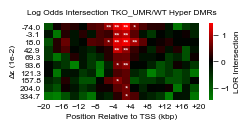

In [16]:
df_list = []

g=['Bivalent', 'H3K4me3', 'H3K27me3']

for gene_type in ['Bivalent']:
    
    df_filt = df_genes.loc[df_genes[category_field_num].str.contains(gene_type)]
    df_filt = df_filt.loc[df_filt[category_field_num] != f'{gene_type} nan']

    print(df_filt[[category_field_num]].value_counts().sort_index())
    
    y_labels = df_filt.groupby(category_field_num).mean()[value_field_num]

    # first we slice up genes to have multiple entries for each window size from the TSS
    df_split = split_gene_intervals(df_filt, category_field_num, value_field_num, skip_cols)
    path_tmp = 'split_genes.bed'
    df_split.to_csv(path_tmp, sep='\t', index=False, header=False)
    
    bedtool_genes = pybedtools.BedTool(path_tmp)
    
    df_bar = intersection(bedtool_dmr, bedtool_genes)

    df_wide = plot_heatmap(df_bar, gene_type, name, y_labels)